# 🏒  NHL Line Analysis
### Top Line Combinations of the 2025-26 Playoff Odds Leaders 
(Data and Predications from: MoneyPuck on March 16, 2026)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify

print("Libraries loaded successfully!")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Libraries loaded successfully!


In [2]:
TOP_TEAMS = ['COL', 'DAL', 'MIN', 'CAR', 'BUF', 'TBL', 'ANA', 'VGK']

lines_2023 = pd.read_csv("lines_2023.csv")
lines_2024 = pd.read_csv("lines_2024.csv")

full_df = pd.concat([lines_2023, lines_2024], axis=0).reset_index(drop=True)

full_df.shape

(6004, 108)

After loading and merging our databases, it looks like we have 6,004 pairings and 108 columns! Let's take a look at all of the possible columns and what the data is formatted like. We can use these 
later to pick out the best line pairings.

In [3]:
full_df.head(5)

,lineId,season,name,team,position,situation,games_played,icetime,iceTimeRank,xGoalsPercentage,...,scoreAdjustedShotsAttemptsAgainst,unblockedShotAttemptsAgainst,scoreAdjustedUnblockedShotAttemptsAgainst,dZoneGiveawaysAgainst,xGoalsFromxReboundsOfShotsAgainst,xGoalsFromActualReboundsOfShotsAgainst,reboundxGoalsAgainst,totalShotCreditAgainst,scoreAdjustedTotalShotCreditAgainst,scoreFlurryAdjustedTotalShotCreditAgainst
0,847793384801858482113,2023,Luostarinen-Lundell-Reinhart,FLA,line,5on5,24,7819.0,172.0,0.60,...,107.37,74.0,74.65,13.0,0.70,0.63,0.63,3.99,4.05,4.01
1,84758258476902,2023,Lindell-Hakanp,DAL,pairing,5on5,61,36226.0,179.0,0.53,...,629.97,429.0,426.70,32.0,3.88,3.94,3.94,22.58,22.65,22.22
2,847579884793168480821,2023,Kunin-Granlund-Zadina,SJS,line,5on5,7,1073.0,65.0,0.25,...,31.61,22.0,22.77,3.0,0.21,0.14,0.14,1.25,1.27,1.26
3,84751818476792,2023,Krug-Leddy,STL,pairing,5on5,42,2424.0,307.0,0.36,...,52.89,33.0,33.12,3.0,0.40,0.68,0.68,2.18,2.16,2.13
4,847793984784838479318,2023,Marner-Matthews-Nylander,TOR,line,5on5,31,2425.0,346.0,0.34,...,47.63,33.0,35.42,5.0,0.43,1.69,1.69,2.62,2.81,2.78


It looks like icetime is recorded in seconds, we will want to add a "clean" time column to make it easier to read and later display, if we want to.

In [4]:
full_df['icetime_mins'] = full_df['icetime'] // 60

In [5]:
full_df['icetime_hours'] = full_df['icetime'] // 3600

In [6]:
full_df.columns.to_list()

['lineId',
 'season',
 'name',
 'team',
 'position',
 'situation',
 'games_played',
 'icetime',
 'iceTimeRank',
 'xGoalsPercentage',
 'corsiPercentage',
 'fenwickPercentage',
 'xOnGoalFor',
 'xGoalsFor',
 'xReboundsFor',
 'xFreezeFor',
 'xPlayStoppedFor',
 'xPlayContinuedInZoneFor',
 'xPlayContinuedOutsideZoneFor',
 'flurryAdjustedxGoalsFor',
 'scoreVenueAdjustedxGoalsFor',
 'flurryScoreVenueAdjustedxGoalsFor',
 'shotsOnGoalFor',
 'missedShotsFor',
 'blockedShotAttemptsFor',
 'shotAttemptsFor',
 'goalsFor',
 'reboundsFor',
 'reboundGoalsFor',
 'freezeFor',
 'playStoppedFor',
 'playContinuedInZoneFor',
 'playContinuedOutsideZoneFor',
 'savedShotsOnGoalFor',
 'savedUnblockedShotAttemptsFor',
 'penaltiesFor',
 'penalityMinutesFor',
 'faceOffsWonFor',
 'hitsFor',
 'takeawaysFor',
 'giveawaysFor',
 'lowDangerShotsFor',
 'mediumDangerShotsFor',
 'highDangerShotsFor',
 'lowDangerxGoalsFor',
 'mediumDangerxGoalsFor',
 'highDangerxGoalsFor',
 'lowDangerGoalsFor',
 'mediumDangerGoalsFor',
 'high

In [7]:
print(full_df["situation"].value_counts())
print(full_df["position"].value_counts())

situation
5on5    6004
Name: count, dtype: int64
position
line       4004
pairing    2000
Name: count, dtype: int64


The database focuses around lines/pairings happening on regular play situations (5on5) with two sets of positions, forwards and defensemen (line, pairing)

Let's now take a look at the teams representated in this database, making sure everything is correct.

In [8]:
full_df['team'].unique()

array(['FLA', 'DAL', 'SJS', 'STL', 'TOR', 'WSH', 'NYR', 'PHI', 'CGY',
       'LAK', 'VAN', 'SEA', 'MIN', 'CBJ', 'NYI', 'ARI', 'BUF', 'TBL',
       'ANA', 'OTT', 'CHI', 'EDM', 'MTL', 'VGK', 'DET', 'CAR', 'NSH',
       'BOS', 'PIT', 'COL', 'WPG', 'NJD', 'UTA'], dtype=object)

We need to account for the relocation of the Arizona Coyotes to Utah Hockey Club

In [9]:
full_df['team'] = full_df['team'].replace('ARI', 'UTA')

In [10]:
full_df['team'].nunique()

32

Now, we need to filter the database down to the eight top teams

In [11]:
df_top = full_df[full_df['team'].isin(TOP_TEAMS)].reset_index().copy()

In [12]:
print(df_top['team'].unique())
print(df_top.shape)

['DAL' 'MIN' 'BUF' 'TBL' 'ANA' 'VGK' 'CAR' 'COL']
(1482, 111)


To summarize how dominant a line or pairing is, we create an offensive and defensive composite score.

The offensive composite using Fenwick (percent of all shots except **blocked** shots) Corsi (percent of **all** shot attempts) and lastly xGoals Percent. This approach emphasizes shot volume and quality equally.

To capture defensive performance, we create a defensive composite score using three metrics: takeaways, penalties against and defensive zone giveaways. Takeaways and penalties reflect active defensive moves, whereas defensive zone giveaways are counted as a negative defensive action, as they directly create scoring chances for opponents. This is reflected in the formula through the inversion, so fewer giveaways contribute to a higher score. This will emphasize strategic play, takeaways and penalties, while penalizing defensive zone giveaways that can potentially lead to high danger scoring chances.


We will apply equal weights to both offensive and defensive composite scores, this approach will emphasize actions equally throughout each line. Future iterations could include exploring different data driven weighting, through PCA (Principal Component Analysis)

Offensive metrics use percentage stats to capture dominance relative to the opponent, while defensive metrics use per-60 rates to measure a unit's own defensive actions independently of opponent behavior.

For the **Offensive Composite Score**, we are asking: When this line is on the ice, who is domaniting in shots and shot qualitiy?

For the **Defensive Composite Score** we are asking: How much defensive activity is this line generating?

In [13]:
df_top['OffensiveCompositeScore'] = (df_top['corsiPercentage'] + df_top['fenwickPercentage']  + df_top['xGoalsPercentage']) / 3 

In [14]:
df_top['OffensiveCompositeScore'].describe()

count    1482.000000
mean        0.503219
std         0.114110
min         0.070000
25%         0.433333
50%         0.506667
75%         0.573333
max         0.933333
Name: OffensiveCompositeScore, dtype: float64

The offensive composite score is a positive number between 0 and 1. A larger positive score indicates more puck possession domenince.

Defensive scores are normalized relative to the top 8 teams (in playoff odds), allowing for direct comparison of defensive preformance across these teams.

In [15]:
df_top["takeawaysForNorm"] = df_top["takeawaysFor"].transform(lambda x: (x - x.min()) / (x.max() - x.min() ))

df_top["dZoneGiveawaysAgainstNorm"] = df_top["dZoneGiveawaysAgainst"].transform(lambda x: (x - x.min()) / (x.max() - x.min() ))

df_top["penaltiesAgainstNorm"] = df_top["penaltiesAgainst"].transform(lambda x: (x - x.min()) / (x.max() - x.min() ))

In [16]:
df_top['DefensiveCompositeScore'] = (df_top['takeawaysForNorm'] + df_top['penaltiesAgainstNorm']  - df_top['dZoneGiveawaysAgainstNorm']) / 3 

In [17]:
df_top['DefensiveCompositeScore'].describe()

count    1482.000000
mean        0.022877
std         0.044203
min        -0.025111
25%         0.002857
50%         0.009589
75%         0.023128
max         0.473750
Name: DefensiveCompositeScore, dtype: float64

The defensive composite score can range from negative to positive. A positive score indicates a line generating more defensive activity (takeaways and penalties drawn) than turnovers. A negative score indicates defensive zone giveaways are outweighing positive defensive actions.

We want to apply a minimum ice time parameter to remove low time on ice line combinations. These low TOI's don't give us enough infomation to draw meaningful conclusions. These are more background noise than true performance.

In [18]:
df_top['icetime_mins'].describe()

count    1482.000000
mean       76.429150
std       133.231151
min        10.000000
25%        16.250000
50%        31.000000
75%        72.000000
max      1185.000000
Name: icetime_mins, dtype: float64

We'll set the minimum ice time threshold at 70 minutes. We want lines/pairings that likely reflect coaching staff's confidence in that line/pairing. We will aslo set the threshold slightly below the mean at 76 minutes so that we retain a broader sample of consistently used line combinations, while still filtering out background noise from rarely deployed pairs/trios.

In [19]:
lines_and_pairs = df_top[df_top['icetime_mins'] >= 70].reset_index().copy()

In [20]:
lines_and_pairs.groupby('team')['lineId'].count()

team
ANA    43
BUF    55
CAR    38
COL    46
DAL    56
MIN    45
TBL    46
VGK    51
Name: lineId, dtype: int64

In [21]:
lines = lines_and_pairs[lines_and_pairs['position'] == 'line'].reset_index(drop=True).copy()
pairs = lines_and_pairs[lines_and_pairs['position'] == 'pairing'].reset_index(drop=True).copy()

In [22]:
top_lines = (lines
    .sort_values('OffensiveCompositeScore', ascending=False)
    .groupby(['team', 'season'])
    .head(3)
    .sort_values(['team', 'season', 'OffensiveCompositeScore'], ascending=[True, True, False])
)[['team', 'season', 'name', 'OffensiveCompositeScore','DefensiveCompositeScore','icetime_mins']]

top_lines

,team,season,name,OffensiveCompositeScore,DefensiveCompositeScore,icetime_mins
58,ANA,2023,Jones-Henrique-Silfverberg,0.563333,0.038839,94.0
13,ANA,2023,Killorn-Carlsson-Terry,0.533333,0.158957,348.0
77,ANA,2023,Zegras-Carlsson-Terry,0.503333,0.030538,85.0
94,ANA,2024,Terry-Strome-Vatrano,0.523333,0.180180,742.0
110,ANA,2024,Gauthier-Carlsson-Killorn,0.506667,0.023393,208.0
127,ANA,2024,Gauthier-Lundestrom-Leason,0.460000,0.006188,75.0
11,BUF,2023,Benson-Krebs-Peterka,0.590000,0.049315,70.0
78,BUF,2023,Benson-Cozens-Peterka,0.550000,0.066317,194.0
62,BUF,2023,Greenway-Mittelstadt-Benson,0.543333,0.038225,113.0
88,BUF,2024,Benson-Krebs-Quinn,0.623333,0.040338,91.0


**Offensive Observations** 

**BUF**: In the 2023-24 season, the top offensive line was the Benson-Krebs-Peterka line with an offensive score of 0.59.This score shows this line was dominating, by controlling the majority of the shot attempts and expected goals while on the ice. This line also produced the highest composite score in 2024-25 season, with the exception of Peterka, as he was replaced by Quinn on that line. The line increased from 0.59 to 0.62. So, not only did they remain elite, they increased puck possession with the replacement. This line warrants further exploration, to better understand what caused the line to continue their dominance (even going so far to increase it as well). Whether that was because of the increased ice time together or the replacement of Peterka with Quinn. Continued use of this line will give us a larger sample size, making the composite score more statistically reliable in whether this truly represents Buffalo's best forward line combination.

**VGK**: In the 2023-24 season, the Dorofeyev-Karlsson-Mantha line had the highest score of 0.61. Another elite dominating team. Unlike Buffalo, this line wasn't the most dominant in the 2024-25 season. That line was Olofsson-Karlsson-Smith, with an offensive score of ~0.64, indicating elite shot quality. This line also however had a negative defensive score. So while, they dominate shot attempts, they struggle to protect the puck. The previous line had a positive (while small) defensive composite score. Using the previous line is a more "safe" line to use, as they might produce less elite domanince, they are able to better protect the puck. A less risk adverse coach might want to use the Dorofeyev-Karlsson-Mantha line. Anthony Mantha, was traded in the 2024-25 season, so this probably what drove this line shake up. Further investigation is necessary to figure out if Mantha, was what improved the defensive component or Smith and Olofesson contributed to the decline in defensive score.

**Limitations**: This metric only captures three forward statistics, Corsi%, Fenwick%, and xGoals%. This doesn't account for other important aspects of forwards, such as goal assists or other individual scoring metrics. In future iterations, incoporating additonal metrics could lead to a more comprehensive look at team lines. Another limitation of this composite score is the sample size. With more line combinations, this statistic could be more reliable. Lastly, a normalization of this score could help put metrics on the same scale for clearer comparison.

In [23]:
top_pairs = (pairs
    .sort_values('DefensiveCompositeScore', ascending=False)
    .groupby(['team', 'season'])
    .head(3)
    .sort_values(['team', 'season', 'DefensiveCompositeScore'], ascending=[True, True, False])
)[['team', 'season', 'name', 'DefensiveCompositeScore', 'OffensiveCompositeScore','icetime_mins']]

top_pairs

,team,season,name,DefensiveCompositeScore,OffensiveCompositeScore,icetime_mins
57,ANA,2023,Mintyukov-Lyubushkin,0.274872,0.453333,543.0
76,ANA,2023,Vaakanainen-Gudas,0.238146,0.510000,492.0
23,ANA,2023,Fowler-Lacombe,0.191817,0.400000,404.0
160,ANA,2024,Lacombe-Gudas,0.180175,0.483333,937.0
119,ANA,2024,Dumoulin-Mintyukov,0.098292,0.480000,261.0
198,ANA,2024,Zellweger-Trouba,0.097064,0.493333,332.0
64,BUF,2023,Dahlin-Jokiharju,0.268481,0.556667,497.0
67,BUF,2023,Power-Jokiharju,0.201268,0.436667,500.0
62,BUF,2023,Dahlin-Samuelsson,0.162091,0.510000,439.0
163,BUF,2024,Dahlin-Byram,0.145968,0.540000,625.0


**Defensive Observations**

**CAR**:

**MIN**:

**Limitations**

Let's now look at these values on a team level using a scatter plot, to give us a visual comparison between teams.

In [84]:
team_colors = {'DAL':'#006847', 'MIN':'#154734',  'BUF':'#003087',  'TBL': '#002868', 'ANA': '#F47A38', 'VGK':'#B4975A',  'CAR':'#CE1126',  'COL': '#6F263D'}


h_lines = lines.groupby('team')[['corsiPercentage', 'fenwickPercentage', 'xGoalsPercentage', 'OffensiveCompositeScore', 'DefensiveCompositeScore']].mean()
h_lines = h_lines.reset_index()
h_lines['Off_norm'] = h_lines['OffensiveCompositeScore'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

h_pairs = pairs.groupby('team')[['corsiPercentage', 'fenwickPercentage', 'xGoalsPercentage', 'OffensiveCompositeScore', 'DefensiveCompositeScore']].mean()
h_pairs = h_pairs.reset_index()
h_pairs['Off_norm'] = h_pairs['OffensiveCompositeScore'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))


Text(0.5, 1.0, 'Top Teams Line Overall Composite Score')

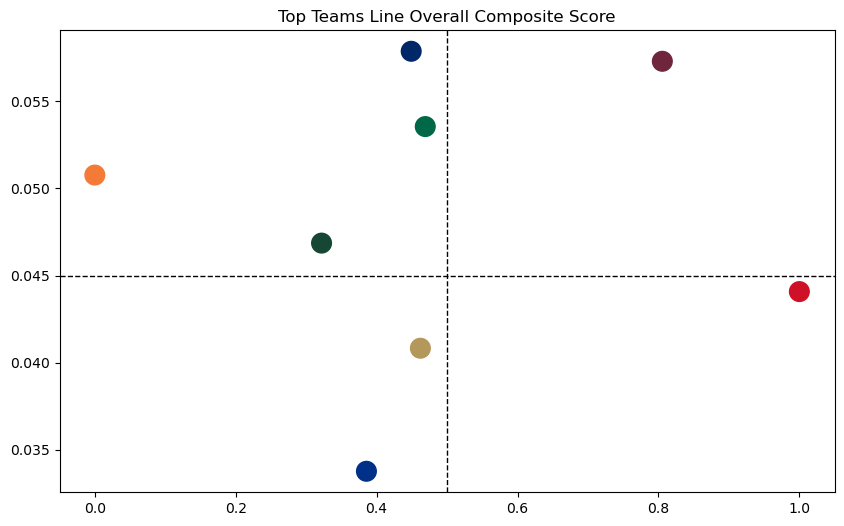

In [129]:
plt.figure(figsize=(10,6))

plt.scatter(x = h_lines['Off_norm'],
            y = h_lines['DefensiveCompositeScore'],
            c = h_lines['team'].map(team_colors),
            s = 200)

plt.axvline(x= 0.5,
           color='black',
           linestyle='--',
           linewidth = 1)

plt.axhline(y= 0.045,
           color='black',
           linestyle='--',
           linewidth = 1)

plt.title('Top Teams Line Overall Composite Score')
            

*Note: Reference lines are set at the visual midpoint of each axis rather than the statistical mean. Since both composite scores are built from different underlying metrics and scales, a mathematical midpoint would not meaningfully separate performance tiers. The quadrants are intended as a qualitative framework for discussing relative team performance, not a precise statistical boundary*

In [138]:
h_lines[['team', 'OffensiveCompositeScore','DefensiveCompositeScore']]

,team,OffensiveCompositeScore,DefensiveCompositeScore
0,ANA,0.459020,0.050769
1,BUF,0.507937,0.033759
2,CAR,0.585909,0.044077
3,COL,0.561228,0.057303
4,DAL,0.518533,0.053554
5,MIN,0.499855,0.046862
6,TBL,0.516000,0.057877
7,VGK,0.517654,0.040824


Text(0.5, 1.0, 'Top Teams Pairing Overall Composite Score')

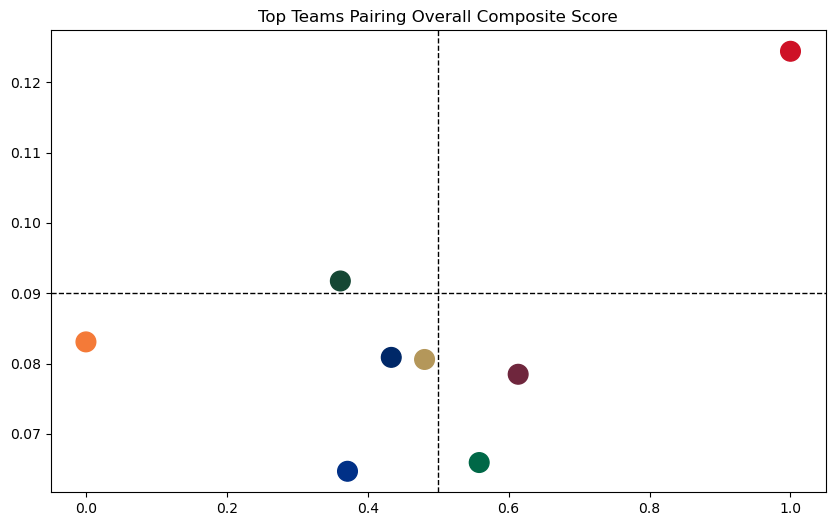

In [130]:
plt.figure(figsize=(10,6))

plt.scatter(x = h_pairs['Off_norm'],
            y = h_pairs['DefensiveCompositeScore'],
            c = h_lines['team'].map(team_colors),
            s = 200)

plt.axvline(x= 0.5,
           color='black',
           linestyle='--',
           linewidth = 1)

plt.axhline(y= 0.090,
           color='black',
           linestyle='--',
           linewidth = 1)

plt.title('Top Teams Pairing Overall Composite Score')

*Note: Reference lines are set at the visual midpoint of each axis rather than the statistical mean. Since both composite scores are built from different underlying metrics and scales, a mathematical midpoint would not meaningfully separate performance tiers. The quadrants are intended as a qualitative framework for discussing relative team performance, not a precise statistical boundary*

In [139]:
h_pairs[['team', 'DefensiveCompositeScore','OffensiveCompositeScore']]

,team,DefensiveCompositeScore,OffensiveCompositeScore
0,ANA,0.083078,0.452692
1,BUF,0.064682,0.492451
2,CAR,0.124398,0.559792
3,COL,0.078475,0.518395
4,DAL,0.065925,0.512473
5,MIN,0.091739,0.491364
6,TBL,0.080877,0.499103
7,VGK,0.080579,0.504167
